# Proyek Eksperimentasi & Pelatihan Model XGBoost Mingguan

**Judul Proyek**: Prediksi Arus Kas Koperasi Menggunakan Algoritma XGBoost untuk Mendukung Pengambilan Keputusan Keuangan  
**Deskripsi**: Notebook ini digunakan khusus untuk proses eksperimentasi, rekayasa fitur (agregasi mingguan & lagging), pemisahan data temporal (Train-Val-Test), serta pelatihan dan evaluasi model XGBoost Regressor.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

## 1. Load Dataset Hasil Pembersihan (`clean_transactions.csv`)
Tahapan: `RAW` -> `cleanData` (yaitu `clean_transactions.csv`).

In [2]:
clean_data_path = '../data/cleaned/clean_transactions.csv'
df = pd.read_csv(clean_data_path)
print(f"Dimensi data transaksi bersih: {df.shape}")
df.head()

Dimensi data transaksi bersih: (190, 5)


,TANGGAL,BULAN,CASH_IN,CASH_OUT,NET_CASH
0,2025-01-02,JANUARI,5236000.0,3426900.0,1809100.0
1,2025-01-03,JANUARI,3733000.0,5458000.0,-1725000.0
2,2025-01-06,JANUARI,7511400.0,7460150.0,51250.0
3,2025-01-07,JANUARI,4180000.0,4262100.0,-82100.0
4,2025-01-08,JANUARI,281250000.0,283708500.0,-2458500.0


## 2. Feature Engineering (Skala Mingguan)
Sesuai ketentuan, dataset mingguan memiliki kolom fitur berikut:
* `week`
* `cash_in`
* `cash_out`
* `net_cash`
* `lag_1`
* `lag_2`
* `rolling_mean_3`
* `growth_rate`
* `target` (dimana $\text{Target}(t) = \text{NetCash}(t+1)$)

In [3]:
df['TANGGAL'] = pd.to_datetime(df['TANGGAL'])
df['week_period'] = df['TANGGAL'].dt.to_period('W')

# Agregasi mingguan
weekly_df = df.groupby('week_period').agg({
    'CASH_IN': 'sum',
    'CASH_OUT': 'sum'
}).reset_index()

weekly_df.rename(columns={
    'week_period': 'week',
    'CASH_IN': 'cash_in',
    'CASH_OUT': 'cash_out'
}, inplace=True)

# Hitung net_cash
weekly_df['net_cash'] = weekly_df['cash_in'] - weekly_df['cash_out']
weekly_df = weekly_df.sort_values('week').reset_index(drop=True)

# Lags
weekly_df['lag_1'] = weekly_df['net_cash'].shift(1)
weekly_df['lag_2'] = weekly_df['net_cash'].shift(2)

# Rolling mean 3 periode dari lag (t-1, t-2, t-3)
weekly_df['rolling_mean_3'] = weekly_df['net_cash'].shift(1).rolling(window=3).mean()

# Growth rate dari lag 2 ke lag 1
weekly_df['growth_rate'] = (weekly_df['lag_1'] - weekly_df['lag_2']) / (weekly_df['lag_2'].abs() + 1e-5)

# Target (NetCash t+1)
weekly_df['target'] = weekly_df['net_cash'].shift(-1)

# Ubah format week ke string menggunakan start_time
weekly_df['week'] = weekly_df['week'].apply(lambda r: r.start_time.strftime('%Y-%m-%d'))

# Drop NaN akibat lagging & target shifting
features_df = weekly_df.dropna().reset_index(drop=True)
print(f"Dimensi dataset fitur mingguan: {features_df.shape}")
features_df.head()

Dimensi dataset fitur mingguan: (39, 9)


,week,cash_in,cash_out,net_cash,lag_1,lag_2,rolling_mean_3,growth_rate,target
0,2025-01-20,41341208.0,52410380.0,-11069172.0,-5484983.0,5357900.0,-1.432767e+04,-2.023719,1858950.0
1,2025-01-27,14047000.0,12188050.0,1858950.0,-11069172.0,-5484983.0,-3.732085e+06,-1.018087,-5052200.0
2,2025-02-03,34578200.0,39630400.0,-5052200.0,1858950.0,-11069172.0,-4.898402e+06,1.167939,-8995143.0
3,2025-02-10,21166500.0,30161643.0,-8995143.0,-5052200.0,1858950.0,-4.754141e+06,-3.717771,9712700.0
4,2025-02-17,29088500.0,19375800.0,9712700.0,-8995143.0,-5052200.0,-4.062798e+06,-0.780441,8662073.0


## 3. Pembagian Data (Temporal Split)
Rasio pembagian data:
* **Train = 70%** (27 baris pertama)
* **Validation = 15%** (6 baris berikutnya)
* **Test = 15%** (6 baris terakhir)

In [4]:
train_df = features_df.iloc[:27].reset_index(drop=True)
val_df = features_df.iloc[27:33].reset_index(drop=True)
test_df = features_df.iloc[33:].reset_index(drop=True)

feature_cols = ['lag_1', 'lag_2', 'rolling_mean_3', 'growth_rate']
target_col = 'target'

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_val:   {X_val.shape}")
print(f"Ukuran X_test:  {X_test.shape}")

Ukuran X_train: (27, 4)
Ukuran X_val:   (6, 4)
Ukuran X_test:  (6, 4)


## 4. Pelatihan Model XGBoost Mingguan

In [5]:
model = XGBRegressor(
    n_estimators=15,
    max_depth=2,
    learning_rate=0.05,
    random_state=42,
    objective='reg:squarederror'
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-rmse:1947812.77221
[1]	validation_0-rmse:1963248.17310
[2]	validation_0-rmse:1978748.92192
[3]	validation_0-rmse:1994221.36200
[4]	validation_0-rmse:2071094.98337
[5]	validation_0-rmse:2087192.78582
[6]	validation_0-rmse:2102924.12032
[7]	validation_0-rmse:2186850.51023
[8]	validation_0-rmse:2201896.57041
[9]	validation_0-rmse:2216447.76469
[10]	validation_0-rmse:2228141.15900
[11]	validation_0-rmse:2239398.97887
[12]	validation_0-rmse:2315514.40722
[13]	validation_0-rmse:2325366.22695
[14]	validation_0-rmse:2334813.67941


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 5. Evaluasi Model pada Data Pengujian (Test Set)
Metrik evaluasi wajib:
* MAE
* RMSE
* MAPE (Mean Absolute Percentage Error)

In [6]:
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test.values - y_pred) / (y_test.values + 1e-5))) * 100

print("=== Hasil Evaluasi pada Test Set ===")
print(f"MAE:  Rp {mae:,.2f}")
print(f"RMSE: Rp {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")

=== Hasil Evaluasi pada Test Set ===
MAE:  Rp 4,634,035.17
RMSE: Rp 7,800,070.49
MAPE: 274.68%


## 6. Visualisasi Aktual vs Prediksi

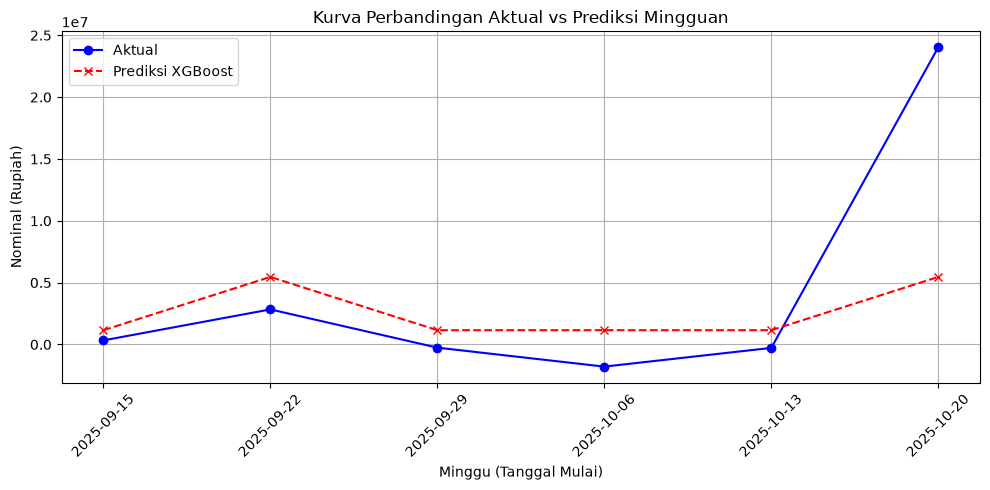

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(test_df['week'], y_test, marker='o', label='Aktual', color='blue')
plt.plot(test_df['week'], y_pred, marker='x', label='Prediksi XGBoost', color='red', linestyle='--')
plt.title('Kurva Perbandingan Aktual vs Prediksi Mingguan')
plt.xlabel('Minggu (Tanggal Mulai)')
plt.ylabel('Nominal (Rupiah)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Serialisasi Model & Daftar Fitur (.pkl)

In [8]:
os.makedirs('../models', exist_ok=True)
with open('../models/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/features.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
print("Serialisasi selesai! model.pkl and features.pkl berhasil disimpan di folder models.")

Serialisasi selesai! model.pkl and features.pkl berhasil disimpan di folder models.
